# EchoNet-Dynamic Exploratory Data Analysis

This notebook performs a comprehensive EDA for the EchoNet Temporal XAI project. It reads the raw EchoNet-Dynamic metadata, processed frame/mask metadata, raw videos when available, and processed masks. It saves every generated table and figure into `echonet_dynamic_eda_outputs` without modifying the raw or processed datasets.


## Running Instructions

1. Run this notebook from the repository root or from `echonet_temporal_xai/eda`; paths are discovered relative to the notebook/repository layout.
2. Install the project requirements first. OpenCV is needed for video and mask inspection. MONAI is imported when available but is not required for this EDA.
3. The notebook does not overwrite existing output files. If a file already exists, a numbered suffix is added.
4. Missing files are reported as warnings so partial EDA can still complete.


## Setup and Utility Functions

This section imports scientific Python tools, discovers project paths, creates the output directory, and defines safe save/read helpers used throughout the notebook.


In [1]:
import sys
!{sys.executable} -m pip install seaborn matplotlib pandas numpy tqdm opencv-python

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [2]:
from __future__ import annotations

import json
import math
import random
import warnings
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

try:
    import monai  # noqa: F401
    MONAI_AVAILABLE = True
except Exception as exc:
    MONAI_AVAILABLE = False
    warnings.warn(f'MONAI is not available; continuing because this EDA does not require it. Details: {exc}')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120
RANDOM_SEED = 42
rng = random.Random(RANDOM_SEED)


def discover_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / 'data' / 'raw').exists() and (candidate / 'data' / 'processed').exists():
            return candidate
        if (candidate / 'echonet_temporal_xai' / 'data' / 'raw').exists():
            return candidate / 'echonet_temporal_xai'
    warnings.warn('Could not find data/raw and data/processed from cwd; using current working directory.')
    return Path.cwd()

PROJECT_ROOT = discover_project_root()
RAW_ROOT = PROJECT_ROOT / 'data' / 'raw'
RAW_DATA_DIR = RAW_ROOT / 'EchoNet-Dynamic' if (RAW_ROOT / 'EchoNet-Dynamic').exists() else RAW_ROOT
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
VIDEOS_DIR = RAW_DATA_DIR / 'Videos'
FILELIST_PATH = RAW_DATA_DIR / 'FileList.csv'
VOLUME_TRACINGS_PATH = RAW_DATA_DIR / 'VolumeTracings.csv'
PROCESSED_METADATA_PATH = PROCESSED_DIR / 'metadata.csv'

EDA_DIR = PROJECT_ROOT / 'eda'
OUTPUT_DIR = EDA_DIR / 'echonet_dynamic_eda_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Raw data dir: {RAW_DATA_DIR}')
print(f'Processed dir: {PROCESSED_DIR}')
print(f'Output dir: {OUTPUT_DIR}')


def safe_output_path(filename: str) -> Path:
    path = OUTPUT_DIR / filename
    if not path.exists():
        return path
    stem, suffix = path.stem, path.suffix
    for idx in range(1, 10_000):
        candidate = OUTPUT_DIR / f'{stem}_{idx:03d}{suffix}'
        if not candidate.exists():
            return candidate
    raise RuntimeError(f'Could not create non-overwriting output path for {filename}')


def save_table(df: pd.DataFrame, filename: str) -> Path:
    path = safe_output_path(filename)
    df.to_csv(path, index=False)
    print(f'Saved table: {path}')
    return path


def save_figure(filename: str) -> Path:
    path = safe_output_path(filename)
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved figure: {path}')
    return path


def read_csv_or_empty(path: Path, name: str) -> pd.DataFrame:
    if not path.exists():
        warnings.warn(f'{name} not found at {path}. Returning an empty table.')
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except Exception as exc:
        warnings.warn(f'Failed to read {name} at {path}: {exc}')
        return pd.DataFrame()


def video_stem(value) -> str:
    return Path(str(value)).stem


def numeric_series(df: pd.DataFrame, column: str) -> pd.Series:
    if column not in df.columns:
        return pd.Series(dtype=float)
    return pd.to_numeric(df[column], errors='coerce').dropna()


def summarize_numeric(series: pd.Series, name: str) -> pd.DataFrame:
    series = pd.to_numeric(series, errors='coerce').dropna()
    if series.empty:
        return pd.DataFrame({'metric': ['count'], name: [0]})
    qs = series.quantile([0.05, 0.25, 0.50, 0.75, 0.95])
    rows = {
        'count': len(series),
        'mean': series.mean(),
        'median': series.median(),
        'std': series.std(),
        'min': series.min(),
        'max': series.max(),
        'p05': qs.loc[0.05],
        'p25': qs.loc[0.25],
        'p50': qs.loc[0.50],
        'p75': qs.loc[0.75],
        'p95': qs.loc[0.95],
    }
    return pd.DataFrame({'metric': list(rows.keys()), name: list(rows.values())})

filelist = read_csv_or_empty(FILELIST_PATH, 'FileList.csv')
tracings = read_csv_or_empty(VOLUME_TRACINGS_PATH, 'VolumeTracings.csv')
processed_meta = read_csv_or_empty(PROCESSED_METADATA_PATH, 'processed metadata.csv')

if not filelist.empty:
    filelist['video_stem'] = filelist['FileName'].map(video_stem)
if not tracings.empty:
    tracings['video_stem'] = tracings['FileName'].map(video_stem)
    tracings['Frame'] = pd.to_numeric(tracings['Frame'], errors='coerce')
if not processed_meta.empty:
    processed_meta['video_stem'] = processed_meta['video_id'].map(video_stem)
    processed_meta['frame_idx'] = pd.to_numeric(processed_meta['frame_idx'], errors='coerce')


/var/folders/w5/w_mnt42s58jg3hd86gbvzpw00000gn/T/ipykernel_58247/1426725484.py:22: UserWarning: MONAI is not available; continuing because this EDA does not require it. Details: No module named 'monai'
  warnings.warn(f'MONAI is not available; continuing because this EDA does not require it. Details: {exc}')


Project root: /Users/jiyoonoh/Documents/Echonet_temporal_XAI
Raw data dir: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/data/raw/EchoNet-Dynamic
Processed dir: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/data/processed
Output dir: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs


In [2]:
import sys
print(sys.executable)

/usr/local/bin/python3


## 1. Dataset Overview

This section summarizes dataset composition from the official EchoNet `FileList.csv`, `VolumeTracings.csv`, and processed image-mask metadata.


In [3]:
overview_rows = []
if filelist.empty:
    warnings.warn('FileList.csv is missing, so video split counts cannot be computed.')
else:
    split_counts = filelist['Split'].astype(str).str.upper().value_counts()
    overview_rows.extend([
        ('number_of_videos', len(filelist)),
        ('train_videos', int(split_counts.get('TRAIN', 0))),
        ('validation_videos', int(split_counts.get('VAL', 0))),
        ('test_videos', int(split_counts.get('TEST', 0))),
        ('unique_studies_or_patients_proxy', filelist['video_stem'].nunique()),
    ])

if tracings.empty:
    labelled_frames = pd.DataFrame(columns=['video_stem', 'Frame'])
else:
    labelled_frames = tracings[['video_stem', 'Frame']].dropna().drop_duplicates()
    per_video_label_counts = labelled_frames.groupby('video_stem')['Frame'].nunique()
    overview_rows.extend([
        ('labelled_ed_frames_estimated', int((per_video_label_counts >= 1).sum())),
        ('labelled_es_frames_estimated', int((per_video_label_counts >= 2).sum())),
        ('unique_labelled_frames', len(labelled_frames)),
    ])

if processed_meta.empty:
    overview_rows.append(('processed_image_mask_pairs', 0))
else:
    overview_rows.append(('processed_image_mask_pairs', len(processed_meta)))

dataset_overview = pd.DataFrame(overview_rows, columns=['metric', 'value'])
save_table(dataset_overview, 'dataset_overview.csv')
dataset_overview


Saved table: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/dataset_overview.csv


,metric,value
0,number_of_videos,10030
1,train_videos,7465
2,validation_videos,1288
3,test_videos,1277
4,unique_studies_or_patients_proxy,10030
5,labelled_ed_frames_estimated,10025
6,labelled_es_frames_estimated,10025
7,unique_labelled_frames,20050
8,processed_image_mask_pairs,20048


## 2. Ejection Fraction (EF) Analysis

This section characterizes the EF distribution, including summary statistics and histogram/KDE/boxplot visualizations.


Saved table: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/ef_summary.csv


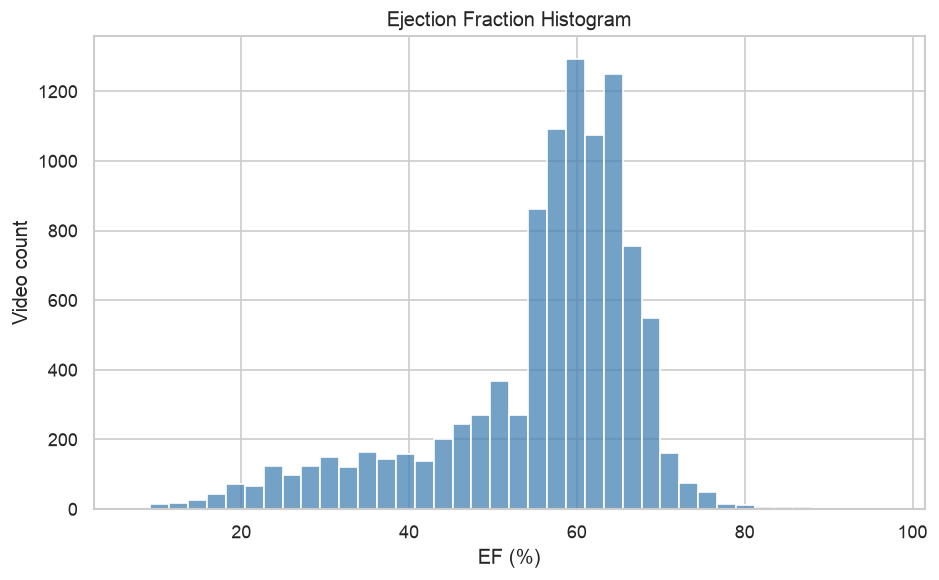

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/ef_histogram.png


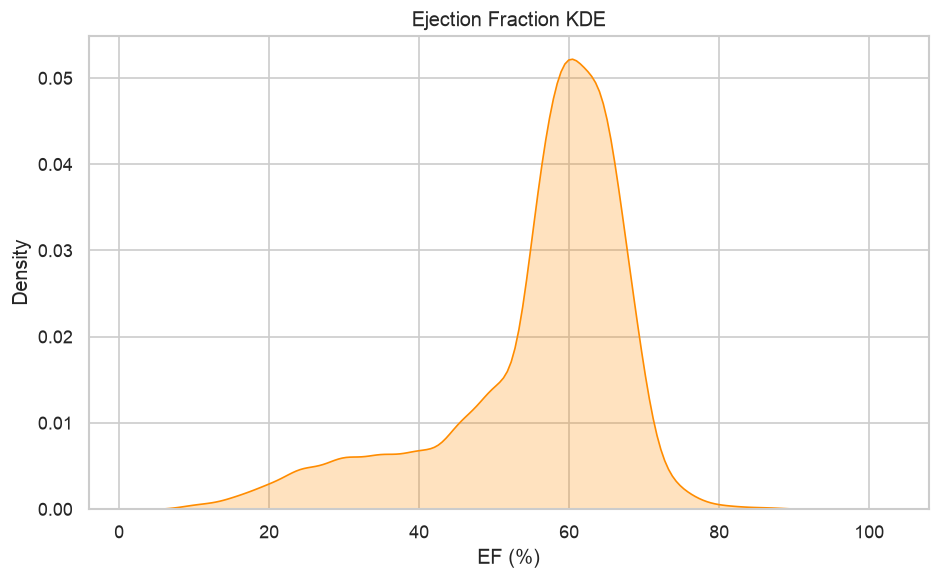

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/ef_kde.png


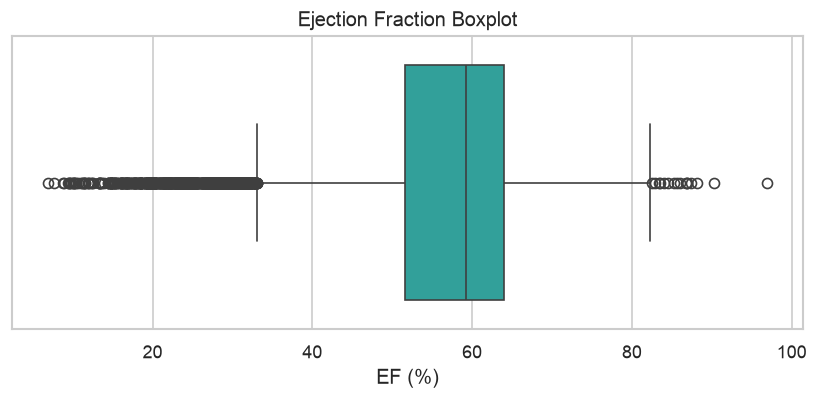

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/ef_boxplot.png


,metric,EF
0,count,10030.000000
1,mean,55.748248
2,median,59.209109
3,std,12.371483
4,min,6.907258
5,max,96.967237
6,p05,27.883672
7,p25,51.601387
8,p50,59.209109
9,p75,63.958740


In [4]:
ef = numeric_series(filelist, 'EF')
ef_summary = summarize_numeric(ef, 'EF')
save_table(ef_summary, 'ef_summary.csv')

if ef.empty:
    warnings.warn('No EF values available for plotting.')
else:
    plt.figure(figsize=(8, 5))
    sns.histplot(ef, bins=40, kde=False, color='steelblue')
    plt.title('Ejection Fraction Histogram')
    plt.xlabel('EF (%)')
    plt.ylabel('Video count')
    save_figure('ef_histogram.png')

    plt.figure(figsize=(8, 5))
    sns.kdeplot(ef, fill=True, color='darkorange')
    plt.title('Ejection Fraction KDE')
    plt.xlabel('EF (%)')
    save_figure('ef_kde.png')

    plt.figure(figsize=(7, 3.5))
    sns.boxplot(x=ef, color='lightseagreen')
    plt.title('Ejection Fraction Boxplot')
    plt.xlabel('EF (%)')
    save_figure('ef_boxplot.png')

ef_summary


## 3. Video Metadata Analysis

This section combines official metadata with optional OpenCV inspection to summarize frame counts, FPS, resolution, and duration.


Optional video integrity pass:   0%|          | 0/10030 [00:00<?, ?it/s]

Saved table: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/video_metadata.csv


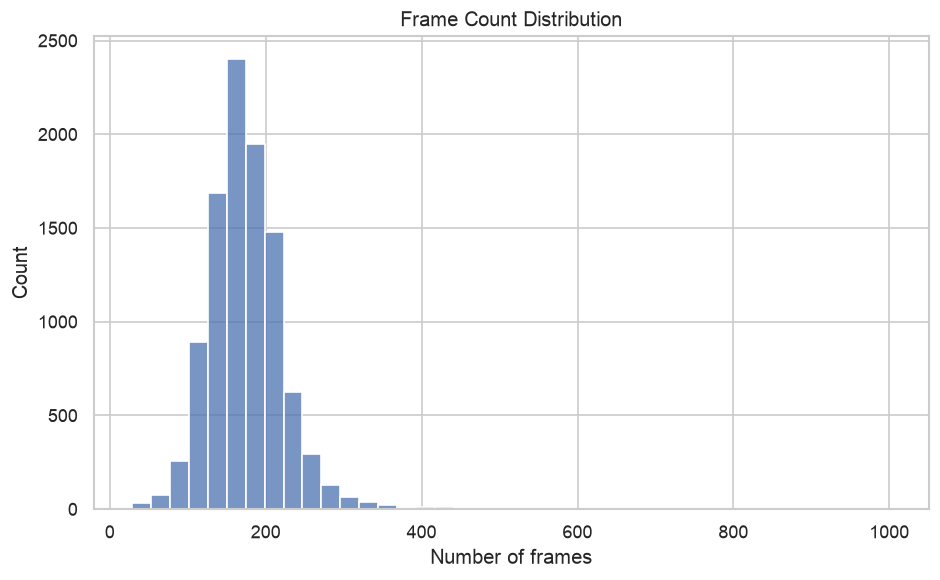

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/frame_count_histogram.png


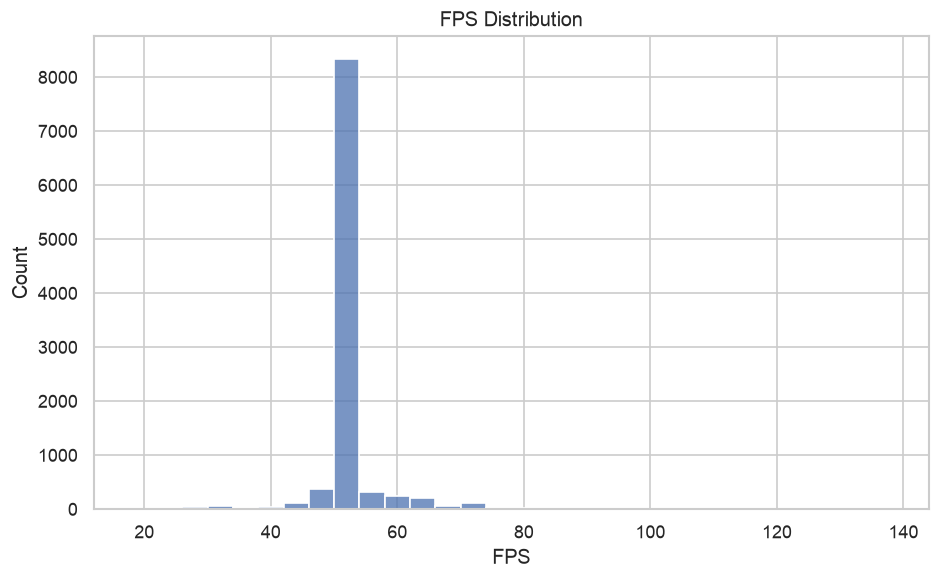

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/fps_histogram.png


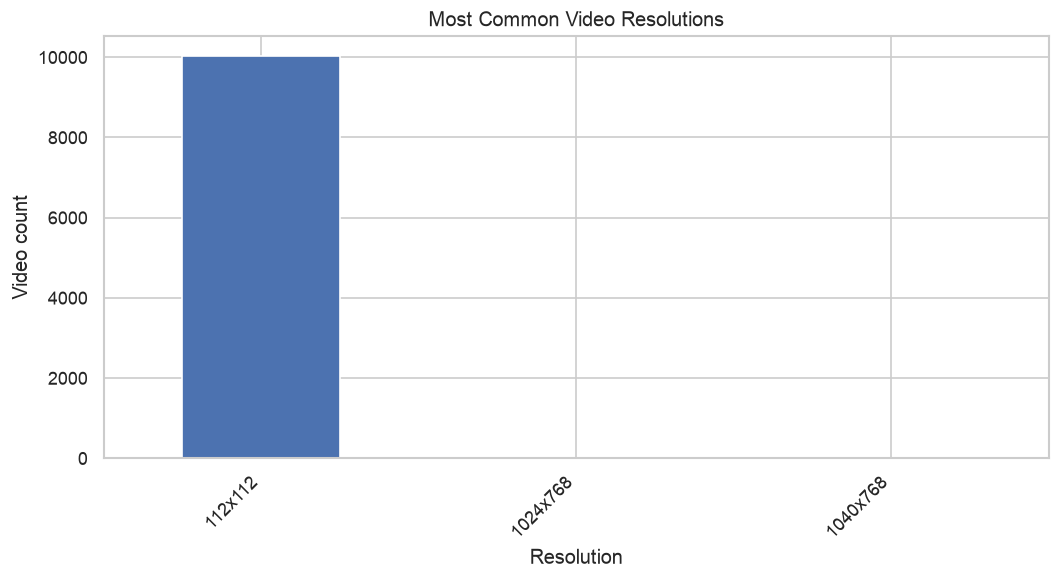

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/resolution_distribution.png


,metric,frame_count,metric_fps,fps
0,count,10030.000000,count,10030.000000
1,mean,176.533998,mean,51.077767
2,median,171.000000,median,50.000000
3,std,57.879145,std,6.238707
4,min,28.000000,min,18.000000
5,max,1002.000000,max,138.000000
6,p05,108.000000,p05,47.000000
7,p25,144.000000,p25,50.000000
8,p50,171.000000,p50,50.000000
9,p75,201.000000,p75,50.000000


In [5]:
video_metadata = pd.DataFrame()
if filelist.empty:
    warnings.warn('FileList.csv missing; video metadata table will be empty.')
else:
    video_metadata = filelist.copy()
    for col in ['NumberOfFrames', 'FPS', 'FrameWidth', 'FrameHeight']:
        if col in video_metadata.columns:
            video_metadata[col] = pd.to_numeric(video_metadata[col], errors='coerce')
    video_metadata['duration_seconds'] = video_metadata['NumberOfFrames'] / video_metadata['FPS'].replace(0, np.nan)
    video_metadata['resolution'] = video_metadata['FrameWidth'].astype('Int64').astype(str) + 'x' + video_metadata['FrameHeight'].astype('Int64').astype(str)

    inspected = []
    if VIDEOS_DIR.exists():
        for row in tqdm(video_metadata.itertuples(index=False), total=len(video_metadata), desc='Optional video integrity pass'):
            stem = getattr(row, 'video_stem')
            path = VIDEOS_DIR / f'{stem}.avi'
            if not path.exists():
                inspected.append({'video_stem': stem, 'video_exists': False, 'cv2_opened': False})
                continue
            cap = cv2.VideoCapture(str(path))
            opened = cap.isOpened()
            inspected.append({
                'video_stem': stem,
                'video_exists': True,
                'cv2_opened': bool(opened),
                'cv2_frame_count': int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) if opened else np.nan,
                'cv2_fps': float(cap.get(cv2.CAP_PROP_FPS)) if opened else np.nan,
                'cv2_width': int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) if opened else np.nan,
                'cv2_height': int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) if opened else np.nan,
            })
            cap.release()
        video_metadata = video_metadata.merge(pd.DataFrame(inspected), on='video_stem', how='left')
    else:
        warnings.warn(f'Videos directory not found: {VIDEOS_DIR}')

save_table(video_metadata, 'video_metadata.csv')

video_summary = pd.concat([
    summarize_numeric(video_metadata.get('NumberOfFrames', pd.Series(dtype=float)), 'frame_count'),
    summarize_numeric(video_metadata.get('FPS', pd.Series(dtype=float)), 'fps').rename(columns={'metric': 'metric_fps'}),
], axis=1)

if not video_metadata.empty:
    plt.figure(figsize=(8, 5))
    sns.histplot(video_metadata['NumberOfFrames'].dropna(), bins=40)
    plt.title('Frame Count Distribution')
    plt.xlabel('Number of frames')
    save_figure('frame_count_histogram.png')

    plt.figure(figsize=(8, 5))
    sns.histplot(video_metadata['FPS'].dropna(), bins=30)
    plt.title('FPS Distribution')
    plt.xlabel('FPS')
    save_figure('fps_histogram.png')

    plt.figure(figsize=(9, 5))
    video_metadata['resolution'].value_counts().head(20).plot(kind='bar')
    plt.title('Most Common Video Resolutions')
    plt.xlabel('Resolution')
    plt.ylabel('Video count')
    plt.xticks(rotation=45, ha='right')
    save_figure('resolution_distribution.png')

video_summary


## 4. Cardiac Cycle Analysis

This section estimates ED/ES frame timing from labelled frames and compares temporal-window coverage for the ConvLSTM stride experiments.


Saved table: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/cardiac_cycle_summary.csv


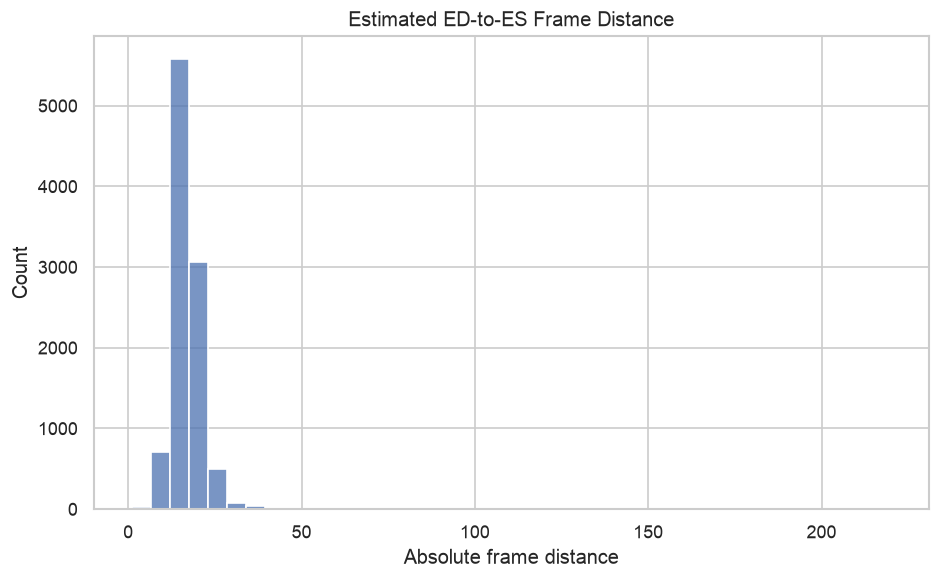

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/ed_es_distance_histogram.png


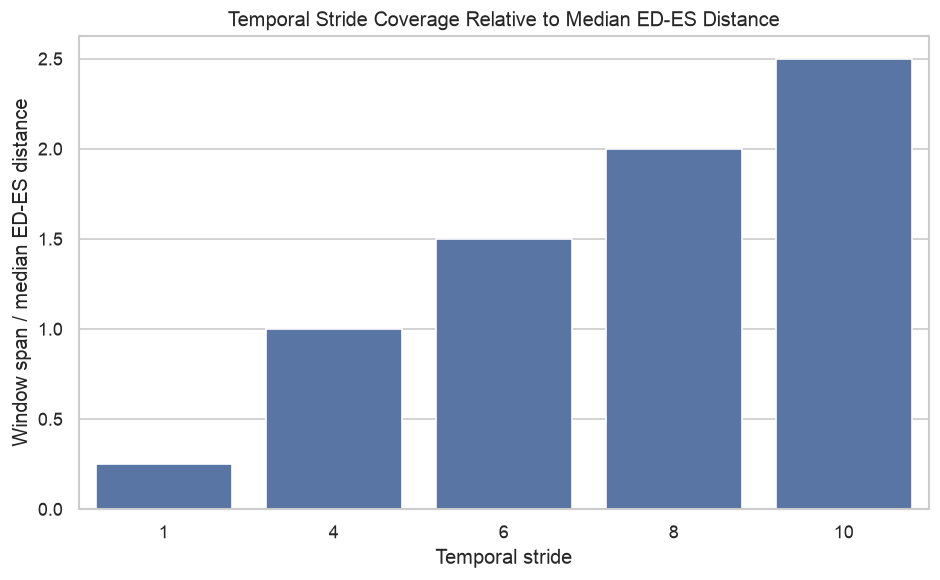

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/temporal_stride_coverage.png


,metric,ed_frame_estimated,metric_es,es_frame_estimated,metric_distance,ed_es_distance
0,count,10025.000000,count,10025.000000,count,10025.000000
1,mean,66.088878,mean,82.841097,mean,16.752219
2,median,56.000000,median,74.000000,median,16.000000
3,std,39.729663,std,40.607964,std,5.089546
4,min,0.000000,min,4.000000,min,1.000000
5,max,664.000000,max,686.000000,max,220.000000
6,p05,2.000000,p05,18.000000,p05,11.000000
7,p25,42.000000,p25,58.000000,p25,14.000000
8,p50,56.000000,p50,74.000000,p50,16.000000
9,p75,90.000000,p75,107.000000,p75,19.000000


In [6]:
strides = [1, 4, 6, 8, 10]
sequence_length = 5
radius = sequence_length // 2

if labelled_frames.empty:
    cardiac_cycle_summary = pd.DataFrame()
    warnings.warn('No labelled frames found; cardiac-cycle analysis skipped.')
else:
    labelled_sorted = labelled_frames.sort_values(['video_stem', 'Frame'])
    frame_lists = labelled_sorted.groupby('video_stem')['Frame'].apply(list)
    cycle_rows = []
    for stem, frames in frame_lists.items():
        frames = sorted([int(x) for x in frames if pd.notna(x)])
        if len(frames) >= 2:
            ed_frame = frames[0]
            es_frame = frames[1]
            cycle_rows.append({'video_stem': stem, 'ed_frame_estimated': ed_frame, 'es_frame_estimated': es_frame, 'ed_es_distance': abs(es_frame - ed_frame)})
    cardiac_df = pd.DataFrame(cycle_rows)
    coverage_rows = []
    median_distance = cardiac_df['ed_es_distance'].median() if not cardiac_df.empty else np.nan
    for stride in strides:
        temporal_span = radius * stride * 2
        coverage_rows.append({
            'stride': stride,
            'window_frame_span': temporal_span,
            'relative_to_median_ed_es_distance': temporal_span / median_distance if median_distance and not np.isnan(median_distance) else np.nan,
        })
    cardiac_cycle_summary = pd.concat([
        summarize_numeric(cardiac_df.get('ed_frame_estimated', pd.Series(dtype=float)), 'ed_frame_estimated'),
        summarize_numeric(cardiac_df.get('es_frame_estimated', pd.Series(dtype=float)), 'es_frame_estimated').rename(columns={'metric': 'metric_es'}),
        summarize_numeric(cardiac_df.get('ed_es_distance', pd.Series(dtype=float)), 'ed_es_distance').rename(columns={'metric': 'metric_distance'}),
    ], axis=1)
    coverage_df = pd.DataFrame(coverage_rows)
    save_table(cardiac_cycle_summary, 'cardiac_cycle_summary.csv')

    plt.figure(figsize=(8, 5))
    sns.histplot(cardiac_df['ed_es_distance'].dropna(), bins=40)
    plt.title('Estimated ED-to-ES Frame Distance')
    plt.xlabel('Absolute frame distance')
    save_figure('ed_es_distance_histogram.png')

    plt.figure(figsize=(8, 5))
    sns.barplot(data=coverage_df, x='stride', y='relative_to_median_ed_es_distance')
    plt.title('Temporal Stride Coverage Relative to Median ED-ES Distance')
    plt.xlabel('Temporal stride')
    plt.ylabel('Window span / median ED-ES distance')
    save_figure('temporal_stride_coverage.png')

cardiac_cycle_summary


## 5. Resolution Distribution

This section tabulates original image resolution frequencies from `FileList.csv` and saves histogram-style summaries.


Saved table: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/resolution_statistics.csv


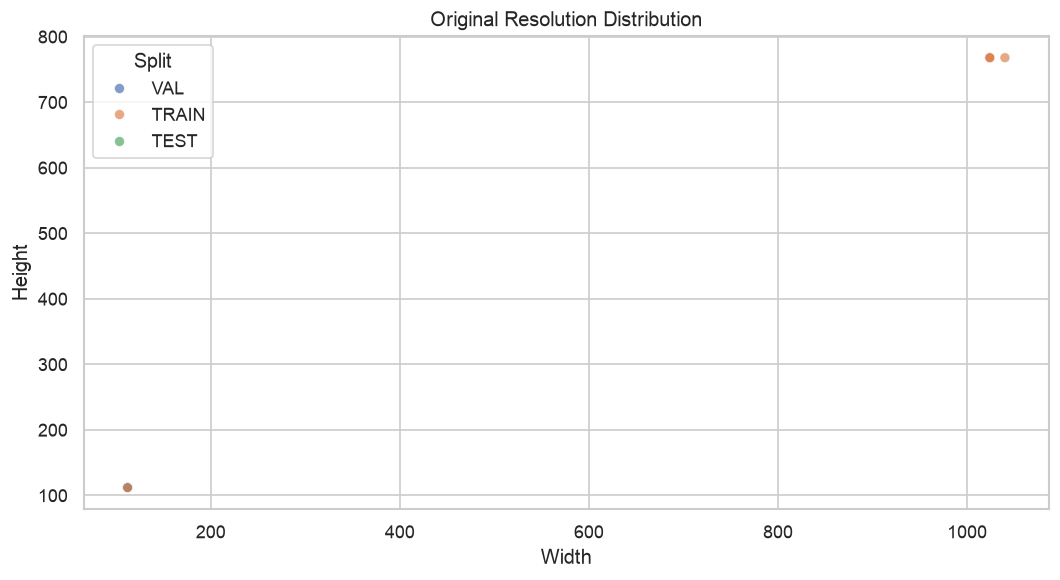

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/resolution_histogram.png


,metric,value,resolution,count
0,mean_width,112.547159,NaN,NaN
1,mean_height,112.392423,NaN,NaN
2,unique_resolutions,3,NaN,NaN
3,most_common_resolution,112x112,NaN,NaN
4,NaN,NaN,112x112,10024.0
5,NaN,NaN,1024x768,5.0
6,NaN,NaN,1040x768,1.0


In [7]:
if video_metadata.empty:
    resolution_statistics = pd.DataFrame()
    warnings.warn('Video metadata unavailable; resolution analysis skipped.')
else:
    resolution_counts = video_metadata['resolution'].value_counts().reset_index()
    resolution_counts.columns = ['resolution', 'count']
    resolution_statistics = pd.DataFrame({
        'metric': ['mean_width', 'mean_height', 'unique_resolutions', 'most_common_resolution'],
        'value': [
            video_metadata['FrameWidth'].mean(),
            video_metadata['FrameHeight'].mean(),
            video_metadata['resolution'].nunique(),
            resolution_counts.iloc[0]['resolution'] if not resolution_counts.empty else np.nan,
        ],
    })
    resolution_statistics = pd.concat([resolution_statistics, resolution_counts.head(20)], axis=0, ignore_index=True)
    save_table(resolution_statistics, 'resolution_statistics.csv')

    plt.figure(figsize=(9, 5))
    sns.scatterplot(data=video_metadata, x='FrameWidth', y='FrameHeight', hue='Split' if 'Split' in video_metadata.columns else None, alpha=0.7)
    plt.title('Original Resolution Distribution')
    plt.xlabel('Width')
    plt.ylabel('Height')
    save_figure('resolution_histogram.png')

resolution_statistics


## 6. Mask Statistics

This section reads processed masks efficiently one at a time and measures LV area and LV percentage of the image.


Reading processed masks:   0%|          | 0/20048 [00:00<?, ?it/s]

Saved table: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/mask_statistics.csv


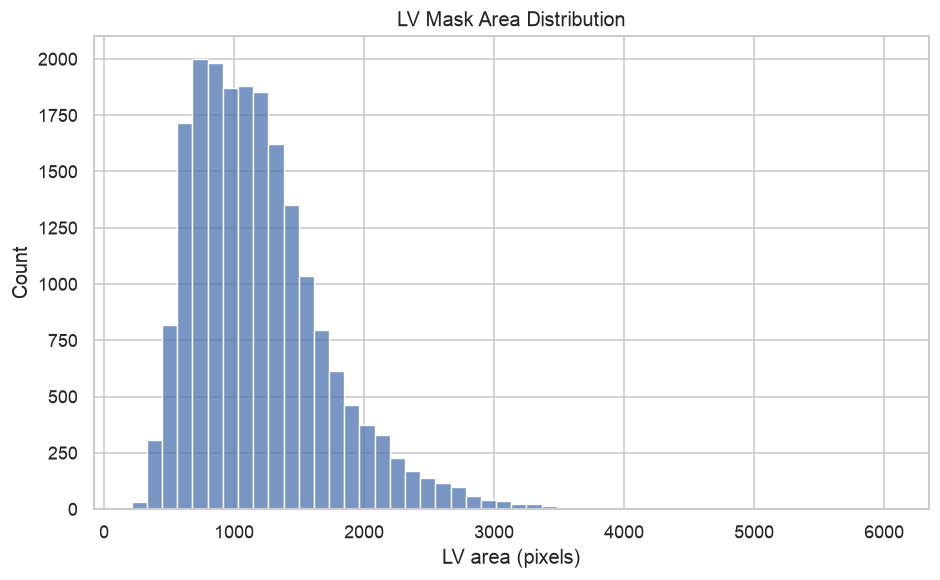

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/lv_area_histogram.png


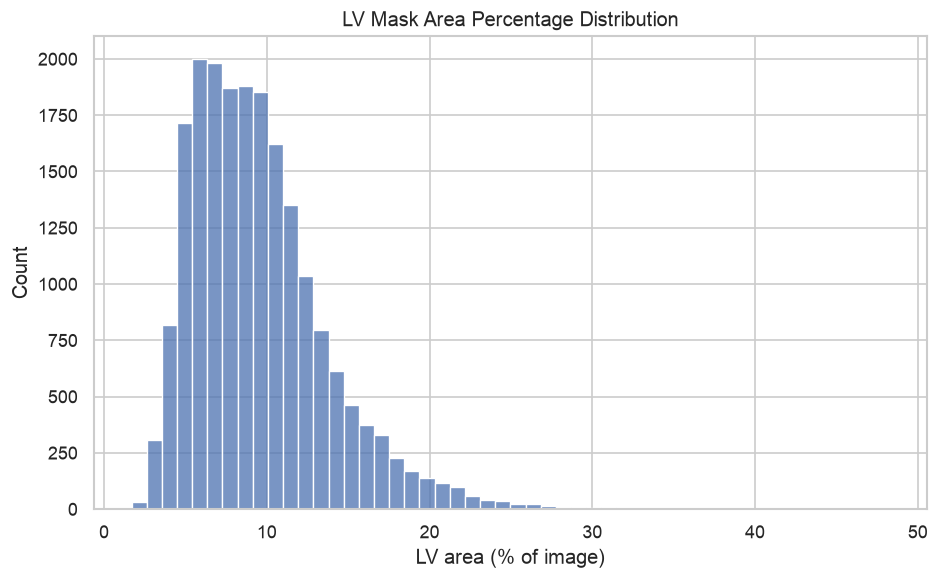

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/lv_area_percentage_histogram.png


,metric,lv_area_pixels,lv_area_percent
0,count,20048.000000,20048.000000
1,max,6051.000000,48.238202
2,mean,1196.485934,9.538313
3,median,1110.000000,8.848852
4,min,212.000000,1.690051
5,p05,546.000000,4.352679
6,p25,802.000000,6.393495
7,p50,1110.000000,8.848852
8,p75,1460.000000,11.639031
9,p95,2198.000000,17.522321


In [8]:
def resolve_processed_path(value) -> Path:
    path = Path(str(value))
    return path if path.is_absolute() else PROCESSED_DIR / path

mask_rows = []
if processed_meta.empty:
    warnings.warn('Processed metadata missing; mask statistics skipped.')
else:
    for row in tqdm(processed_meta.itertuples(index=False), total=len(processed_meta), desc='Reading processed masks'):
        mask_path = resolve_processed_path(getattr(row, 'mask_path'))
        item = {'video_stem': getattr(row, 'video_stem'), 'frame_idx': getattr(row, 'frame_idx'), 'mask_path': str(mask_path)}
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            item.update({'mask_readable': False, 'lv_area_pixels': np.nan, 'lv_area_percent': np.nan, 'height': np.nan, 'width': np.nan})
        else:
            area = float((mask > 0).sum())
            total = float(mask.size)
            item.update({'mask_readable': True, 'lv_area_pixels': area, 'lv_area_percent': 100.0 * area / total, 'height': mask.shape[0], 'width': mask.shape[1]})
        mask_rows.append(item)
mask_stats = pd.DataFrame(mask_rows)
mask_summary = summarize_numeric(mask_stats.get('lv_area_pixels', pd.Series(dtype=float)), 'lv_area_pixels')
mask_summary = mask_summary.merge(summarize_numeric(mask_stats.get('lv_area_percent', pd.Series(dtype=float)), 'lv_area_percent'), on='metric', how='outer')
save_table(mask_stats, 'mask_statistics.csv')

if not mask_stats.empty and mask_stats['lv_area_pixels'].notna().any():
    plt.figure(figsize=(8, 5))
    sns.histplot(mask_stats['lv_area_pixels'].dropna(), bins=50)
    plt.title('LV Mask Area Distribution')
    plt.xlabel('LV area (pixels)')
    save_figure('lv_area_histogram.png')

    plt.figure(figsize=(8, 5))
    sns.histplot(mask_stats['lv_area_percent'].dropna(), bins=50)
    plt.title('LV Mask Area Percentage Distribution')
    plt.xlabel('LV area (% of image)')
    save_figure('lv_area_percentage_histogram.png')

mask_summary


## 7. ED vs ES Analysis

This section estimates ED/ES samples as the first two processed labelled frames per video and compares LV mask areas.


Saved table: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/ed_es_statistics.csv


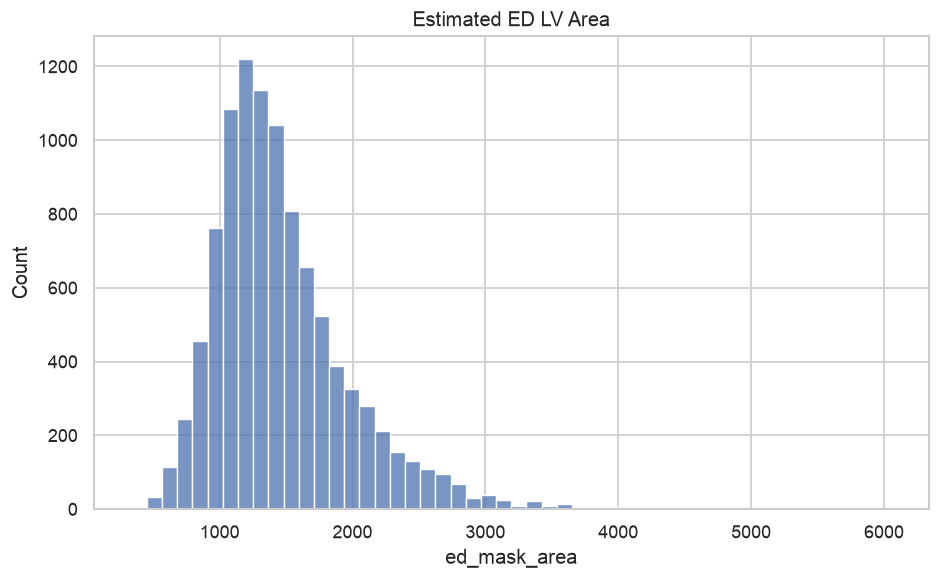

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/ed_area_histogram.png


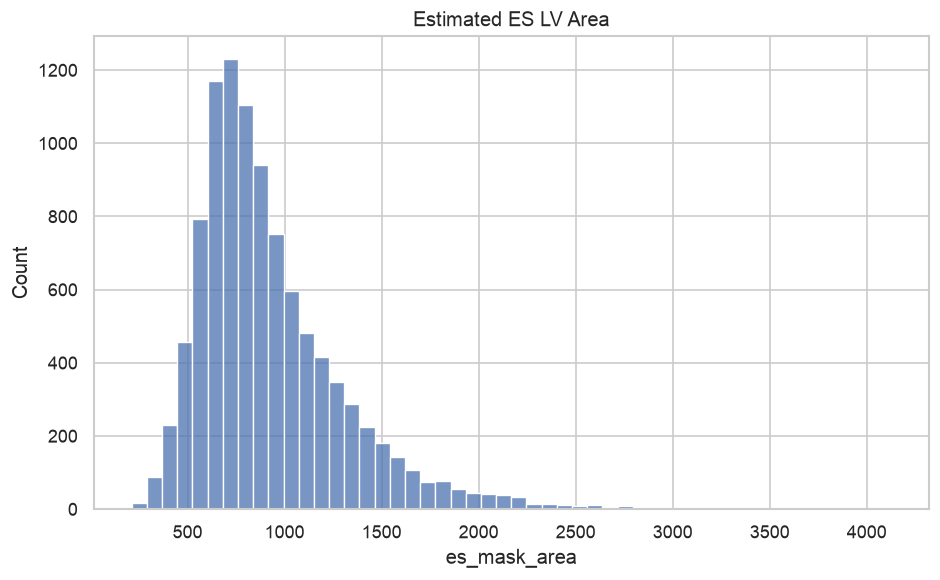

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/es_area_histogram.png


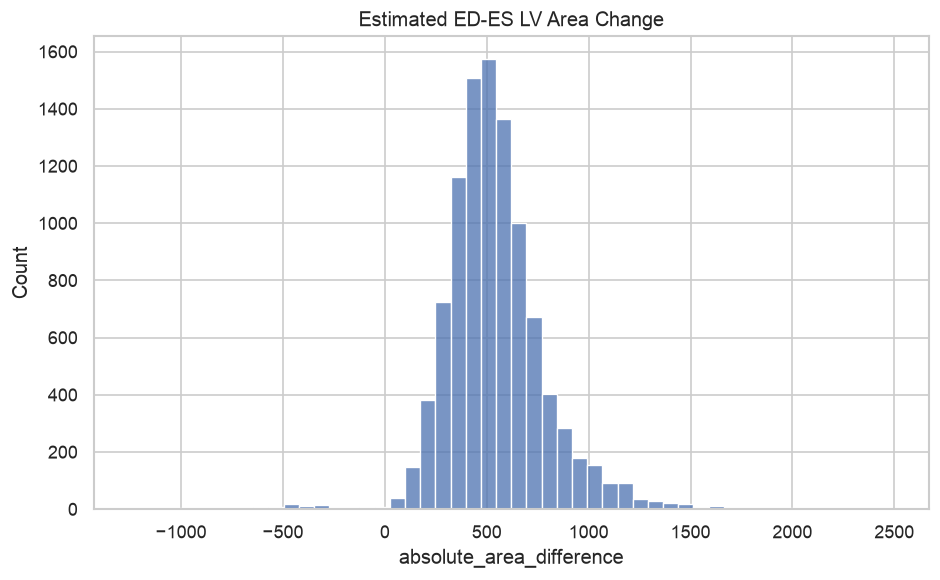

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/ed_es_change_histogram.png


,video_stem,ed_frame_idx_estimated,es_frame_idx_estimated,ed_mask_area,es_mask_area,absolute_area_difference,relative_area_difference_percent
0,0X100009310A3BD7FC,46,61,1342.0,562.0,780.0,58.122206
1,0X1002E8FBACD08477,3,18,1219.0,680.0,539.0,44.216571
2,0X1005D03EED19C65B,24,35,836.0,472.0,364.0,43.540670
3,0X10075961BC11C88E,91,108,1074.0,673.0,401.0,37.337058
4,0X10094BA0A028EAC3,137,156,2054.0,1673.0,381.0,18.549172


In [9]:
if mask_stats.empty:
    ed_es_stats = pd.DataFrame()
    warnings.warn('Mask statistics unavailable; ED-vs-ES analysis skipped.')
else:
    ordered = mask_stats.sort_values(['video_stem', 'frame_idx']).dropna(subset=['lv_area_pixels'])
    ed_es_rows = []
    for stem, group in ordered.groupby('video_stem'):
        if len(group) < 2:
            continue
        ed = group.iloc[0]
        es = group.iloc[1]
        ed_area = float(ed['lv_area_pixels'])
        es_area = float(es['lv_area_pixels'])
        ed_es_rows.append({
            'video_stem': stem,
            'ed_frame_idx_estimated': ed['frame_idx'],
            'es_frame_idx_estimated': es['frame_idx'],
            'ed_mask_area': ed_area,
            'es_mask_area': es_area,
            'absolute_area_difference': ed_area - es_area,
            'relative_area_difference_percent': 100.0 * (ed_area - es_area) / ed_area if ed_area > 0 else np.nan,
        })
    ed_es_stats = pd.DataFrame(ed_es_rows)
    save_table(ed_es_stats, 'ed_es_statistics.csv')

    for column, filename, title in [
        ('ed_mask_area', 'ed_area_histogram.png', 'Estimated ED LV Area'),
        ('es_mask_area', 'es_area_histogram.png', 'Estimated ES LV Area'),
        ('absolute_area_difference', 'ed_es_change_histogram.png', 'Estimated ED-ES LV Area Change'),
    ]:
        if column in ed_es_stats.columns and ed_es_stats[column].notna().any():
            plt.figure(figsize=(8, 5))
            sns.histplot(ed_es_stats[column].dropna(), bins=50)
            plt.title(title)
            plt.xlabel(column)
            save_figure(filename)

ed_es_stats.head()


## 8. Data Quality Analysis

This section checks for missing/corrupt videos, missing/corrupt masks, invalid image-mask pairs, and metadata outliers.


In [10]:
quality_rows = []
if not filelist.empty:
    missing_videos = 0
    corrupt_videos = 0
    for stem in tqdm(filelist['video_stem'], desc='Checking videos'):
        path = VIDEOS_DIR / f'{stem}.avi'
        if not path.exists():
            missing_videos += 1
            continue
        cap = cv2.VideoCapture(str(path))
        ok = cap.isOpened() and int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) > 0
        corrupt_videos += int(not ok)
        cap.release()
    quality_rows.extend([('missing_videos', missing_videos), ('corrupt_or_unreadable_videos', corrupt_videos)])

if not processed_meta.empty:
    missing_masks = 0
    corrupt_masks = 0
    invalid_pairs = 0
    for row in tqdm(processed_meta.itertuples(index=False), total=len(processed_meta), desc='Checking processed pairs'):
        image_path = resolve_processed_path(getattr(row, 'image_path'))
        mask_path = resolve_processed_path(getattr(row, 'mask_path'))
        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE) if image_path.exists() else None
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE) if mask_path.exists() else None
        missing_masks += int(not mask_path.exists())
        corrupt_masks += int(mask_path.exists() and mask is None)
        invalid_pairs += int(image is None or mask is None or (image is not None and mask is not None and image.shape != mask.shape))
    quality_rows.extend([('missing_masks', missing_masks), ('corrupt_or_unreadable_masks', corrupt_masks), ('invalid_image_mask_pairs', invalid_pairs)])

if not video_metadata.empty:
    fc = video_metadata['NumberOfFrames'].dropna()
    if not fc.empty:
        q1, q3 = fc.quantile([0.25, 0.75])
        iqr = q3 - q1
        outlier_count = int(((fc < q1 - 1.5 * iqr) | (fc > q3 + 1.5 * iqr)).sum())
        quality_rows.append(('outlier_frame_counts_iqr', outlier_count))
    quality_rows.append(('unique_resolutions', int(video_metadata['resolution'].nunique())))

data_quality_report = pd.DataFrame(quality_rows, columns=['check', 'value'])
save_table(data_quality_report, 'data_quality_report.csv')
data_quality_report


Checking videos:   0%|          | 0/10030 [00:00<?, ?it/s]

Checking processed pairs:   0%|          | 0/20048 [00:00<?, ?it/s]

Saved table: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/data_quality_report.csv


,check,value
0,missing_videos,0
1,corrupt_or_unreadable_videos,0
2,missing_masks,0
3,corrupt_or_unreadable_masks,0
4,invalid_image_mask_pairs,0
5,outlier_frame_counts_iqr,292
6,unique_resolutions,3


## 9. Visual Inspection

This section saves representative raw frames and processed image-mask overlays for qualitative inspection.


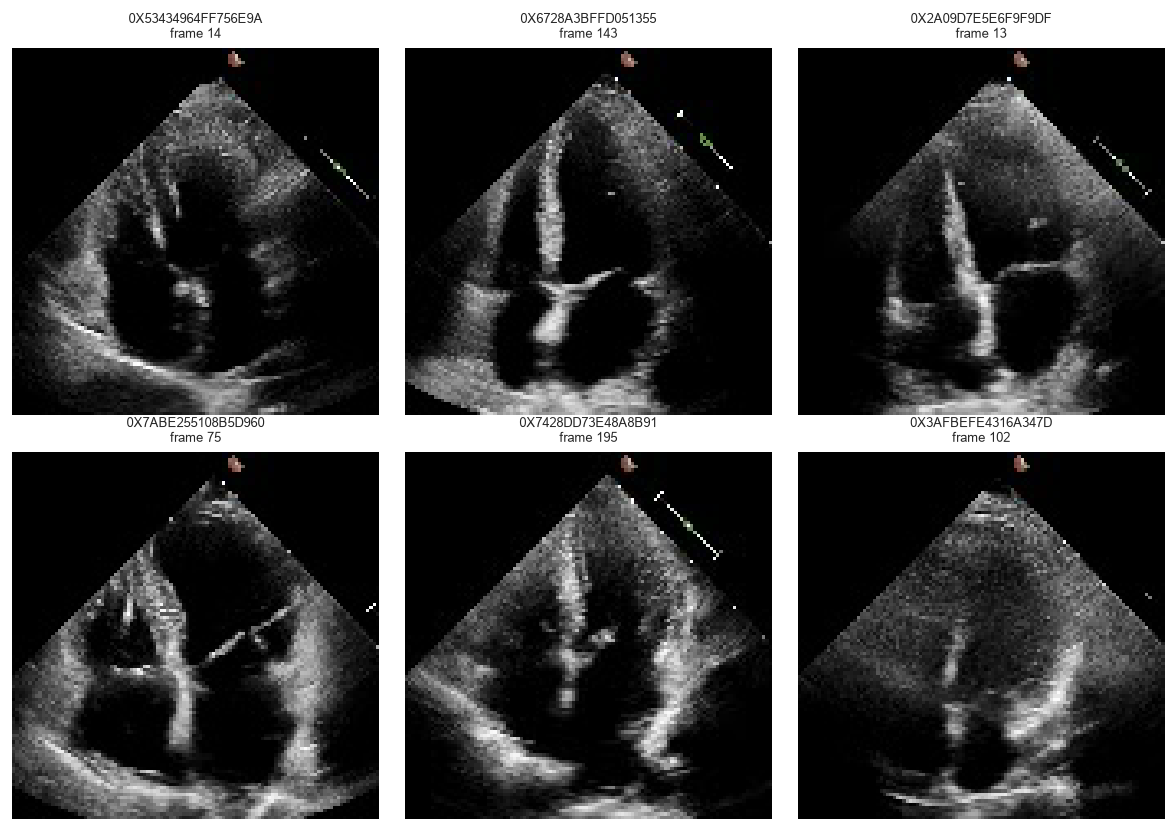

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/random_examples.png


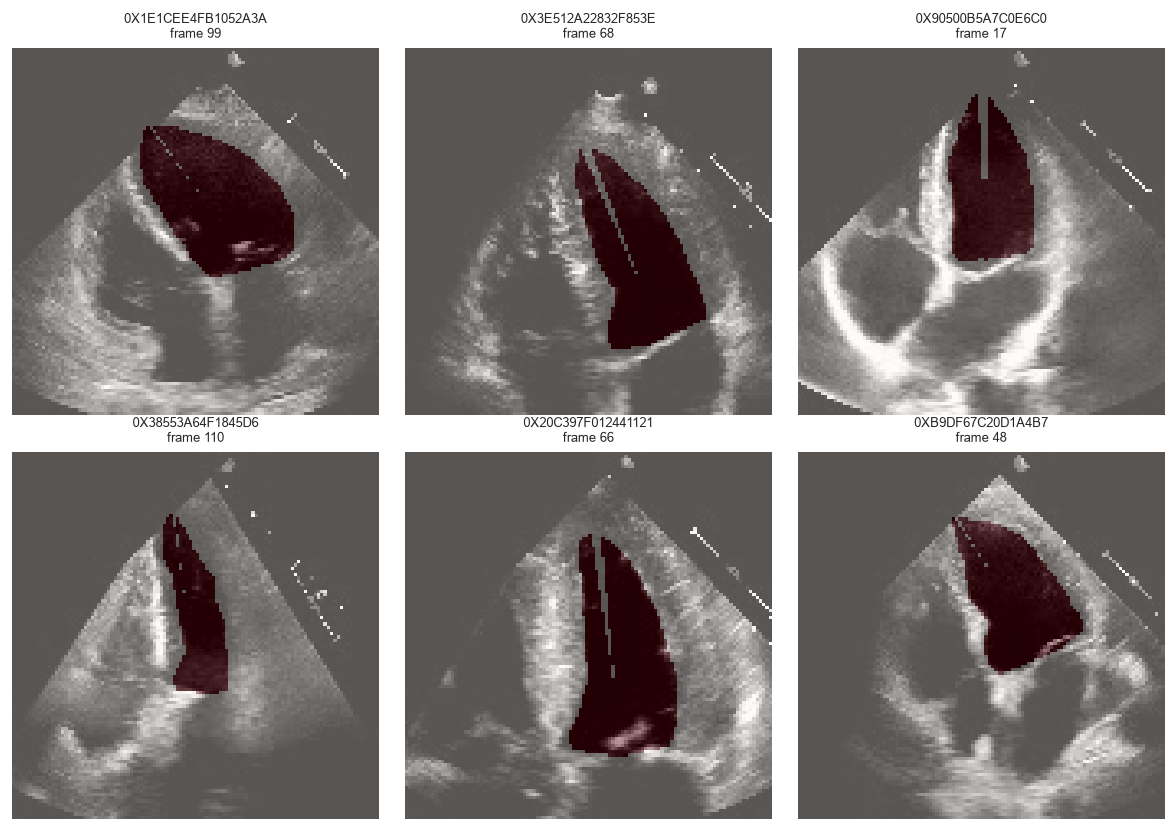

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/overlay_examples.png


In [11]:
def read_random_video_frame(video_path: Path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return None
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if frame_count <= 0:
        cap.release()
        return None
    idx = rng.randrange(frame_count)
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, frame = cap.read()
    cap.release()
    if not ok:
        return None
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), idx

examples = []
if not filelist.empty and VIDEOS_DIR.exists():
    stems = list(filelist['video_stem'])
    rng.shuffle(stems)
    for stem in stems[:12]:
        result = read_random_video_frame(VIDEOS_DIR / f'{stem}.avi')
        if result is not None:
            frame, idx = result
            examples.append((stem, idx, frame))
        if len(examples) >= 6:
            break

if examples:
    fig, axes = plt.subplots(2, 3, figsize=(10, 7))
    for ax, (stem, idx, frame) in zip(axes.flat, examples):
        ax.imshow(frame, cmap='gray')
        ax.set_title(f'{stem}\nframe {idx}', fontsize=8)
        ax.axis('off')
    save_figure('random_examples.png')
else:
    warnings.warn('No readable raw video examples found.')

overlay_examples = []
if not processed_meta.empty:
    sample_rows = processed_meta.sample(min(6, len(processed_meta)), random_state=RANDOM_SEED)
    for row in sample_rows.itertuples(index=False):
        image = cv2.imread(str(resolve_processed_path(getattr(row, 'image_path'))), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(resolve_processed_path(getattr(row, 'mask_path'))), cv2.IMREAD_GRAYSCALE)
        if image is None or mask is None:
            continue
        overlay_examples.append((getattr(row, 'video_stem'), int(getattr(row, 'frame_idx')), image, mask > 0))

if overlay_examples:
    fig, axes = plt.subplots(2, 3, figsize=(10, 7))
    for ax, (stem, idx, image, mask) in zip(axes.flat, overlay_examples):
        ax.imshow(image, cmap='gray')
        ax.imshow(mask, cmap='Reds', alpha=0.35)
        ax.set_title(f'{stem}\nframe {idx}', fontsize=8)
        ax.axis('off')
    save_figure('overlay_examples.png')
else:
    warnings.warn('No readable overlay examples found.')


## 10. Temporal Modeling Analysis

This section estimates whether labelled center frames have enough valid neighboring video frames for ConvLSTM windows at strides 1, 4, 6, 8, and 10.


Saved table: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/temporal_stride_statistics.csv


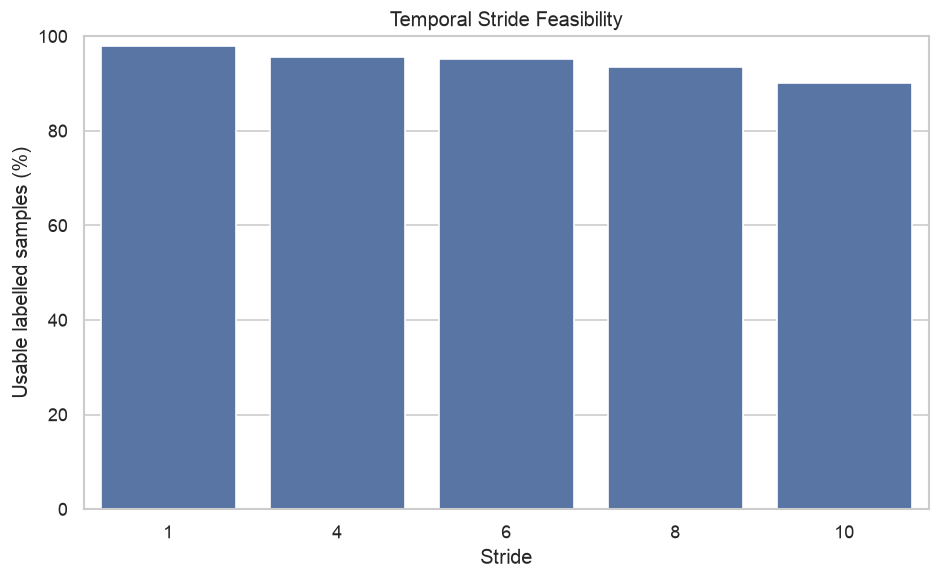

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/temporal_stride_feasibility.png


,stride,labelled_samples,usable_samples,mean_available_context_frames,usable_percent
0,1,20048,19643,4.965882,97.979848
1,4,20048,19158,4.919443,95.560654
2,6,20048,19076,4.909068,95.151636
3,8,20048,18756,4.891161,93.555467
4,10,20048,18071,4.855347,90.138667


In [12]:
if processed_meta.empty or filelist.empty:
    temporal_stride_statistics = pd.DataFrame()
    warnings.warn('Processed metadata or FileList missing; temporal feasibility skipped.')
else:
    frame_lookup = filelist.set_index('video_stem')['NumberOfFrames'].apply(pd.to_numeric, errors='coerce').to_dict()
    temporal_rows = []
    for row in processed_meta.itertuples(index=False):
        stem = getattr(row, 'video_stem')
        center = int(getattr(row, 'frame_idx'))
        n_frames = frame_lookup.get(stem, np.nan)
        if pd.isna(n_frames):
            continue
        for stride in strides:
            offsets = [offset * stride for offset in range(-radius, radius + 1)]
            indices = [center + offset for offset in offsets]
            valid = all(0 <= idx < int(n_frames) for idx in indices)
            available = sum(0 <= idx < int(n_frames) for idx in indices)
            temporal_rows.append({'video_stem': stem, 'frame_idx': center, 'stride': stride, 'valid_full_window': valid, 'available_context_frames': available, 'required_context_frames': sequence_length})
    temporal_detail = pd.DataFrame(temporal_rows)
    temporal_stride_statistics = temporal_detail.groupby('stride').agg(
        labelled_samples=('valid_full_window', 'size'),
        usable_samples=('valid_full_window', 'sum'),
        mean_available_context_frames=('available_context_frames', 'mean'),
    ).reset_index()
    temporal_stride_statistics['usable_percent'] = 100.0 * temporal_stride_statistics['usable_samples'] / temporal_stride_statistics['labelled_samples']
    save_table(temporal_stride_statistics, 'temporal_stride_statistics.csv')

    plt.figure(figsize=(8, 5))
    sns.barplot(data=temporal_stride_statistics, x='stride', y='usable_percent')
    plt.title('Temporal Stride Feasibility')
    plt.xlabel('Stride')
    plt.ylabel('Usable labelled samples (%)')
    plt.ylim(0, 100)
    save_figure('temporal_stride_feasibility.png')

temporal_stride_statistics


## 11. XAI Preparation Analysis

This section computes LV centroids, LV size distribution, a mean LV mask, and a mean LV location heatmap to support future Grad-CAM analyses.


Computing LV centroids:   0%|          | 0/20048 [00:00<?, ?it/s]

Saved table: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/xai_preparation_statistics.csv


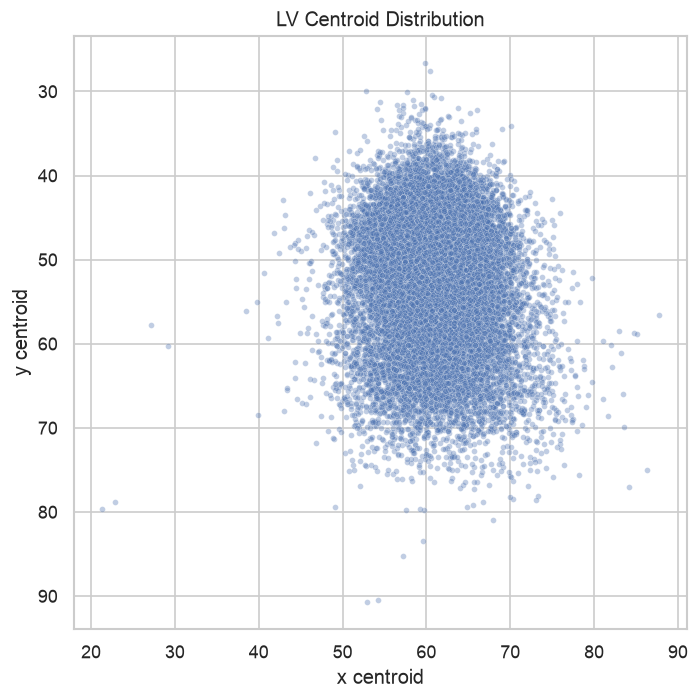

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/lv_centroid_distribution.png


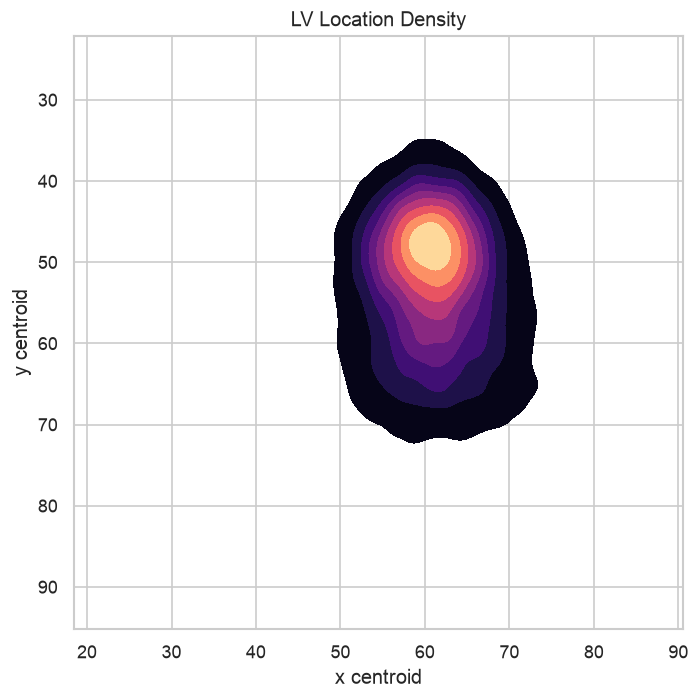

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/lv_location_density.png


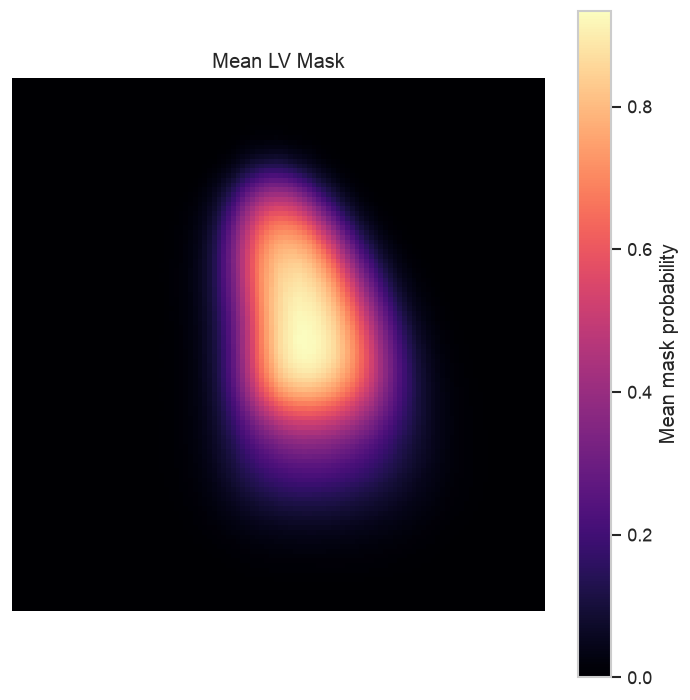

Saved figure: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/mean_lv_mask.png


,metric,centroid_x,metric_y,centroid_y,metric_area,lv_area_pixels
0,count,20048.000000,count,20048.000000,count,20048.000000
1,mean,60.884103,mean,52.264238,mean,1196.485934
2,median,60.833655,median,50.941026,median,1110.000000
3,std,4.912238,std,7.769749,std,532.753839
4,min,21.250435,min,26.632937,min,212.000000
5,max,87.733894,max,90.724206,max,6051.000000
6,p05,53.068997,p05,41.429727,p05,546.000000
7,p25,57.731008,p25,46.604513,p25,802.000000
8,p50,60.833655,p50,50.941026,p50,1110.000000
9,p75,63.905210,p75,57.410024,p75,1460.000000


In [13]:
xai_rows = []
mean_mask = None
mean_centroid_heatmap = None
count_masks = 0
if mask_stats.empty:
    warnings.warn('Mask statistics unavailable; XAI preparation skipped.')
else:
    for row in tqdm(mask_stats.itertuples(index=False), total=len(mask_stats), desc='Computing LV centroids'):
        mask_path = Path(getattr(row, 'mask_path'))
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue
        binary = mask > 0
        if mean_mask is None:
            mean_mask = np.zeros(binary.shape, dtype=np.float64)
            mean_centroid_heatmap = np.zeros(binary.shape, dtype=np.float64)
        if binary.shape != mean_mask.shape:
            binary = cv2.resize(binary.astype(np.uint8), (mean_mask.shape[1], mean_mask.shape[0]), interpolation=cv2.INTER_NEAREST) > 0
        ys, xs = np.where(binary)
        if len(xs) == 0:
            continue
        cx, cy = float(xs.mean()), float(ys.mean())
        mean_mask += binary.astype(np.float64)
        mean_centroid_heatmap[int(round(cy)), int(round(cx))] += 1
        count_masks += 1
        xai_rows.append({'video_stem': getattr(row, 'video_stem'), 'frame_idx': getattr(row, 'frame_idx'), 'centroid_x': cx, 'centroid_y': cy, 'lv_area_pixels': float(binary.sum()), 'image_width': binary.shape[1], 'image_height': binary.shape[0]})

xai_stats = pd.DataFrame(xai_rows)
xai_summary = pd.DataFrame()
if not xai_stats.empty:
    xai_summary = pd.concat([
        summarize_numeric(xai_stats['centroid_x'], 'centroid_x'),
        summarize_numeric(xai_stats['centroid_y'], 'centroid_y').rename(columns={'metric': 'metric_y'}),
        summarize_numeric(xai_stats['lv_area_pixels'], 'lv_area_pixels').rename(columns={'metric': 'metric_area'}),
    ], axis=1)
save_table(xai_stats if not xai_stats.empty else xai_summary, 'xai_preparation_statistics.csv')

if not xai_stats.empty:
    plt.figure(figsize=(6, 6))
    sns.scatterplot(data=xai_stats, x='centroid_x', y='centroid_y', s=12, alpha=0.35)
    plt.gca().invert_yaxis()
    plt.title('LV Centroid Distribution')
    plt.xlabel('x centroid')
    plt.ylabel('y centroid')
    save_figure('lv_centroid_distribution.png')

    plt.figure(figsize=(6, 6))
    sns.kdeplot(data=xai_stats, x='centroid_x', y='centroid_y', fill=True, cmap='magma', thresh=0.05)
    plt.gca().invert_yaxis()
    plt.title('LV Location Density')
    plt.xlabel('x centroid')
    plt.ylabel('y centroid')
    save_figure('lv_location_density.png')

if mean_mask is not None and count_masks > 0:
    plt.figure(figsize=(6, 6))
    plt.imshow(mean_mask / count_masks, cmap='magma')
    plt.colorbar(label='Mean mask probability')
    plt.title('Mean LV Mask')
    plt.axis('off')
    save_figure('mean_lv_mask.png')

xai_summary


## 12. Final Summary Report

This final section collects the most important observations into a compact CSV summary for manuscript methods/results drafting.


In [14]:
summary_items = []
def add_summary(item, value):
    summary_items.append({'item': item, 'value': value})

add_summary('videos_total', len(filelist) if not filelist.empty else np.nan)
add_summary('processed_image_mask_pairs', len(processed_meta) if not processed_meta.empty else np.nan)
add_summary('ef_mean', float(ef.mean()) if not ef.empty else np.nan)
add_summary('ef_median', float(ef.median()) if not ef.empty else np.nan)
add_summary('median_frame_count', float(video_metadata['NumberOfFrames'].median()) if not video_metadata.empty else np.nan)
add_summary('median_fps', float(video_metadata['FPS'].median()) if not video_metadata.empty else np.nan)
add_summary('median_ed_es_distance_estimated', float(cardiac_df['ed_es_distance'].median()) if 'cardiac_df' in globals() and not cardiac_df.empty else np.nan)
add_summary('mean_lv_area_pixels', float(mask_stats['lv_area_pixels'].mean()) if not mask_stats.empty else np.nan)
add_summary('mean_lv_area_percent', float(mask_stats['lv_area_percent'].mean()) if not mask_stats.empty else np.nan)
if 'temporal_stride_statistics' in globals() and not temporal_stride_statistics.empty:
    for row in temporal_stride_statistics.itertuples(index=False):
        add_summary(f'stride_{int(row.stride)}_usable_percent', float(row.usable_percent))
add_summary('xai_centroid_x_mean', float(xai_stats['centroid_x'].mean()) if 'xai_stats' in globals() and not xai_stats.empty else np.nan)
add_summary('xai_centroid_y_mean', float(xai_stats['centroid_y'].mean()) if 'xai_stats' in globals() and not xai_stats.empty else np.nan)

final_eda_summary = pd.DataFrame(summary_items)
save_table(final_eda_summary, 'final_eda_summary.csv')
final_eda_summary


Saved table: /Users/jiyoonoh/Documents/Echonet_temporal_XAI/eda/echonet_dynamic_eda_outputs/final_eda_summary.csv


,item,value
0,videos_total,10030.000000
1,processed_image_mask_pairs,20048.000000
2,ef_mean,55.748248
3,ef_median,59.209109
4,median_frame_count,171.000000
5,median_fps,50.000000
6,median_ed_es_distance_estimated,16.000000
7,mean_lv_area_pixels,1196.485934
8,mean_lv_area_percent,9.538313
9,stride_1_usable_percent,97.979848
